---
title: "Phylogenetic OU Regression with Julia"
format: html
jupyter: julia-1.11
---

# Including phylogenetic uncertainty - Julia version

Often, we do not have a single phylogeny but a set of phylogenies, e.g., from a Bayesian phylogenetic inference. When using phylogenetic control, we want to marginalize over the phylogenetic uncertainty. Doing this in R + Stan is possible but cumbersome and computationally expensive. Therefore I will explore re-implementations of the R/Stan models in Julia + Turing.jl, and in Python + NumPyro.

Let's start with Julia.


## Preparing the environment

In [1]:
cd(@__DIR__)
using Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/projects/research/OU_logistic_example/code`


## Loading the required packages

In [2]:
using CodecZlib: GzipDecompressor
using CSV
using DataFrames
using DataFramesMeta
using Distributions
using Downloads
using DynamicPPL
using FileIO
using Glob
using LinearAlgebra
using LogDensityProblems
using MCMCChains
using Optim
using Phylo
using Pigeons
using Pipe
using Printf
using ProgressMeter
using Random
using RCall
using Statistics
using StatsBase
using StatsFuns
using StatsPlots
using Tar
using Main.Threads
using Turing
plotly()
include("bridge_sampling.jl")

bridge_sampling (generic function with 1 method)

## Data

Now we will use the 902 posterior samples of the EDGE tree.

In [3]:
# Create data directory if it doesn't exist
isdir("../data") || mkpath("../data")

# Paths
tgz_url = "https://github.com/rbouckaert/global-language-tree-pipeline/releases/download/v1.0.0/all_trees.tgz"
tgz_file = "../data/all_trees.tgz"
tar_file = "../data/all_trees.tar"
tree_dir = "../data/all_trees/"

# Download and extract
if !isdir(tree_dir)
    Downloads.download(tgz_url, tgz_file)

    # Decompress .tgz to .tar
    open(tgz_file) do f_in
        open(tar_file, "w") do f_out
            write(f_out, transcode(GzipDecompressor, read(f_in)))
        end
    end

    # Extract .tar archive
    Tar.extract(tar_file, tree_dir)
    # Move all files from ../data/all_trees/all_trees to ../data/all_trees
    inner_dir = joinpath(tree_dir, "all_trees")
    if isdir(inner_dir)
        for f in readdir(inner_dir; join=true)
            mv(f, joinpath(tree_dir, basename(f)); force=true)
        end
        rm(inner_dir; force=true, recursive=true)
    end
    # Clean up
    rm(tgz_file)
    rm(tar_file)
end


# Load all Newick trees
tree_files = glob("*.tree", tree_dir)

trees = [parsenewick(read(f, String)) for f in tree_files]

# Optionally strip suffixes
for tree in trees
    for tip in getleaves(tree)
        tip.name = split(tip.name, "_")[1]
    end
end

## Grambank data

We use the same sample as in the previous notebook

In [4]:
d = @pipe CSV.File("../data/grambank_vals_pruned.csv") |>
          DataFrame |>
          sort(_, :Language_ID)
taxa = d.Language_ID;

Now we prune the trees to only include the languages in the data.

In [5]:
pruned_trees = [deepcopy(t) for t in trees]
for t in pruned_trees
    droptips!(t, setdiff(getleafnames(t), taxa))
end

Here is a little helperfunction to be used later:


In [6]:
# Alternative: Create a more structured view of LOO results
function format_loo_results(loo_dict)
    # Extract the main metrics
    estimates = DataFrame(
        metric=["LOOIC", "SE of LOOIC", "elpd_loo", "SE of elpd_loo"],
        value=[
            loo_dict["looic"],
            loo_dict["se_looic"],
            loo_dict["elpd_loo"],
            loo_dict["se_p_loo"]
        ]
    )
    return estimates
end

format_loo_results (generic function with 1 method)

In [7]:
first(d, 10)

Row,Language_ID,GB133,GB193,x,y
,String15,Int64,Int64,Int64,Int64
1,adan1251,1,2,1,1
2,ajas1235,0,1,0,0
3,alab1254,1,1,0,1
4,alya1239,0,2,1,0
5,arch1244,1,1,0,1
6,aree1239,1,2,1,1
7,arig1246,0,1,0,0
8,awar1249,1,2,1,1
9,band1344,0,1,0,0


In this notebook, I will focus on the correlation models, where both variables are modeled as stochastic. We start with the vanilla correlation model, which does not use phylogenetic information.

First we implement the model in Turing.jl. The model is a simple multivariate logistic regression with a correlation structure.

In [8]:
@model function vanilla_correlation(N)
    # Priors
    mu ~ MvNormal(zeros(2), 2.)
    sigma ~ filldist(LogNormal(0.0, 1.0), 2)  # Standard deviations for each variable
    L_R ~ LKJCholesky(2, 2.)
    rho := L_R.L[2, 1]
    z_raw ~ filldist(MvNormal(zeros(2), 1), N)
    z := diagm(sigma) * L_R.L * z_raw .+ mu

    x ~ product_distribution(BernoulliLogit.(z[1, :]))
    y ~ product_distribution(BernoulliLogit.(z[2, :]))
end

vanilla_correlation (generic function with 2 methods)

In this notebook, I will use the `Pigeons` package to fit the model. Pigeons is a Julia package implementing *parallel tempering* sampling. It is based on Slice sampling, i.e., a sampling method not using automatic differentiation. This makes it possible to include discrete variables alongside continuous ones, which is useful handling phylogenetic uncertainty.

Parallel tempering is comparatively slow. I still chose it because it computes both the posterior and the marginal likelihood in one swoop. 


┌ Info: Found initial step size
│   ϵ = 0.8
└ @ Turing.Inference /home/gjaeger/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
┌ Info: Found initial step size
│   ϵ = 0.8
└ @ Turing.Inference /home/gjaeger/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
┌ Info: Found initial step size
│   ϵ = 0.8
└ @ Turing.Inference /home/gjaeger/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207
┌ Info: Found initial step size
│   ϵ = 0.8
└ @ Turing.Inference /home/gjaeger/.julia/packages/Turing/IXycm/src/mcmc/hmc.jl:207


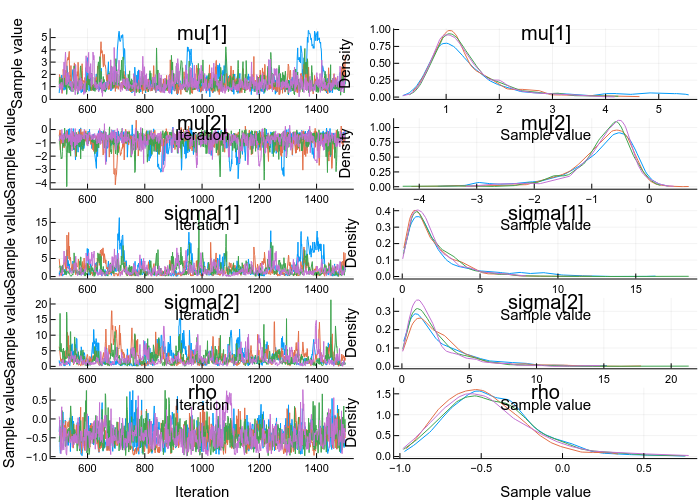

In [9]:
chain_vanilla_correlation = Turing.sample(
    vanilla_correlation(nrow(d)) | (x=d.x, y=d.y),
    NUTS(),
    MCMCThreads(),
    1_000,   # samples
    4,        # chains
    progress = false,
)


nms = [nm for nm in names(chain_vanilla_correlation) if !occursin("z", string(nm)) && !(occursin("L_R", string(nm)))]

describe(chain_vanilla_correlation[:, nms, :])

plot(chain_vanilla_correlation[:, nms, :])

In [10]:
hpd(chain_vanilla_correlation[:, ["mu[1]", "mu[2]", "sigma[1]", "sigma[2]", "rho"], :])

HPD
  parameters     lower     upper 
      Symbol   Float64   Float64 

       mu[1]    0.3241    3.0372
       mu[2]   -2.0786    0.0770
    sigma[1]    0.0183    5.7257
    sigma[2]    0.0237    7.3660
         rho   -0.9518    0.0772


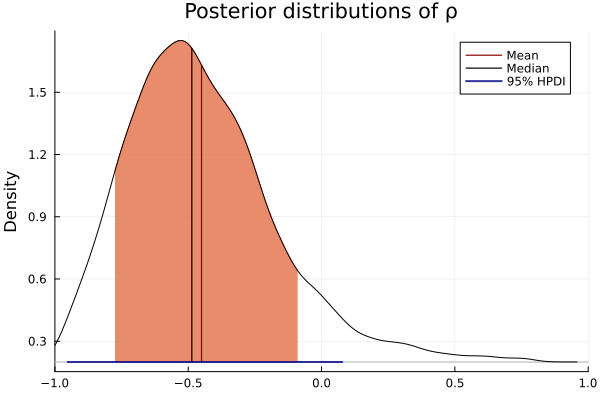

In [11]:
gr()
ridgelineplot(chain_vanilla_correlation, [:rho], title="Posterior distributions of ρ", xlims=(-1, 1))


In [13]:
model_vanilla_correlation = vanilla_correlation(nrow(d)) | (x=d.x, y=d.y)

pt_vanilla_correlation = pigeons(
    target=TuringLogPotential(model_vanilla_correlation),
    # n_chains = 2,
    multithreaded=true,
    record=[traces; record_default()]
)

──────────────────────────────────────────────────────────────────────────────────────────────────
  scans        Λ        time(s)    allc(B)  log(Z₁/Z₀)   min(α)     mean(α)    min(αₑ)   mean(αₑ) 
────────── ────────── ────────── ────────── ────────── ────────── ────────── ────────── ──────────
        2       4.27       1.29   2.68e+09       -138     0.0466      0.526          1          1 
        4       3.84       2.25    5.3e+09       -132     0.0015      0.574          1          1 
        8       4.72        3.8   1.06e+10       -134     0.0546      0.476          1          1 
       16       4.48       8.37   2.12e+10       -130     0.0881      0.502          1          1 
       32       4.19       18.1   4.27e+10       -132       0.38      0.534          1          1 
       64       4.56         32   8.53e+10       -131      0.414      0.494          1          1 
      128       4.36       64.5    1.7e+11       -131      0.416      0.515          1          1 
      256 

PT(checkpoint = false, ...)

In [14]:
println(stepping_stone(pt_vanilla_correlation))

-131.0534300175268


# Prior and posterior predictive sampling for vanilla_correlation


In [ ]:
plotly()
# Prior predictive sampling 
prior_chain = Turing.sample(vanilla_correlation(nrow(d)), Prior(), length(chain_vanilla_correlation))

# Posterior predictive sampling - use the fitted chain



x_prior = Int.(hcat([prior_chain[:, "x[$i]", :] for i in 1:nrow(d)]...))

y_prior = Int.(hcat([prior_chain[:, "y[$i]", :] for i in 1:nrow(d)]...))


x_posterior = hcat(
    [rand(product_distribution(BernoulliLogit.(chain_vanilla_correlation[:,"z[1, $i]", :]))) for i in 1:nrow(d)]...
)

y_posterior = hcat(
    [rand(product_distribution(BernoulliLogit.(chain_vanilla_correlation[:,"z[2, $i]", :]))) for i in 1:nrow(d)]...
)



prior_cors = [cor(x_prior[i, :], y_prior[i, :]) for i in 1:size(x_prior, 1)]
# Remove NaNs from prior_cors
prior_cors = filter(!isnan, prior_cors)

posterior_cors = [cor(x_posterior[i, :], y_posterior[i, :]) for i in 1:size(x_posterior, 1)]
# Remove NaNs from posterior_cors
posterior_cors = filter(!isnan, posterior_cors)

df = DataFrame(
    cor = vcat(prior_cors, posterior_cors),
    type = vcat(fill("prior", length(prior_cors)), fill("posterior", length(posterior_cors)))
)

@df df density(:cor, group=:type, title="Prior and Posterior Correlation Distributions", xlabel="Correlation", ylabel="Density")
vline!([cor(d.x, d.y)])

In [ ]:
loglik_vanilla_correlation = hcat([logpdf.(BernoulliLogit.(chain_vanilla_correlation[:,"z[1, $i]", :]), d.x[i]) .+ logpdf.(BernoulliLogit.(chain_vanilla_correlation[:,"z[2, $i]", :]), d.y[i]) for i in 1:nrow(d)]...)


#| vscode: {languageId: julia}
# Compute LOOIC
loo_vanilla_correlation = convert(
    Dict,
    R"
    library(loo)
    loo($(loglik_vanilla_correlation))
    ",
);

In [ ]:
println("LOO Results:")
loo_results_vanilla_correlation = format_loo_results(loo_vanilla_correlation)
println(loo_results_vanilla_correlation)

In [ ]:
model_vanilla_correlation = vanilla_correlation(nrow(d)) | (x=d.x, y=d.y)

ldf_vanilla_correlation = LogDensityFunction(model_vanilla_correlation)

params = Symbol.(keys(ldf_vanilla_correlation.varinfo))

chain_names = names(chain_vanilla_correlation)

params_1d = []
for pm in params
    append!(
        params_1d,
        [String(x) for x in chain_names if occursin(string(pm), string(x))]
    )
end

samples = Array(chain_vanilla_correlation[:, Symbol.(params_1d), :])

f_vanilla_correlation(x) = LogDensityProblems.logdensity(ldf_vanilla_correlation, x)

In [ ]:
marginal_vanilla_correlation = bridge_sampling(samples, f_vanilla_correlation)

println("Marginal likelihood for vanilla_correlation: ", marginal_vanilla_correlation)

And now the model for logistic correlation with a Brownian motion phylogenetic structure.

Here I define a continuous variable `latent_index` that is sampled from a uniform distribution between 0 and the number of trees. This variable is mapped to an integer via the ceiling function and then used to select a tree from the set of pruned trees. The `clamp` function ensures that the index is within the valid range of tree indices.


In [ ]:
function get_vcv(tree; taxa=taxa)
    root = getroot(tree)
    tips = getleaves(tree)
    tip_names = getleafnames(tree)
    vcv = zeros(length(tips), length(tips))

    # Compute VCV matrix (upper triangle only)
    for i in 1:length(tips)
        for j in i:length(tips)
            if i == j
                # Diagonal: total distance from root to tip (variance)
                vcv[i, j] = distance(tree, root, tips[i])
            else
                # Off-diagonal: shared evolutionary time (distance from root to MRCA)
                vcv[j, i] = vcv[i, j] = distance(tree, root, mrca(tree, [tips[i], tips[j]]))
            end
        end
    end
    return vcv[indexin(tip_names, taxa), indexin(tip_names, taxa)]
end

In [ ]:
scaled_vcv_matrices = [get_vcv(t) ./ 100 for t in pruned_trees]
scaled_cholesky_matrices = [cholesky(m).L for m in scaled_vcv_matrices]

## Brownian Correlation Model


In [ ]:
@model function brownian_correlation(scaled_cholesky_matrices, taxa)
    n = length(scaled_cholesky_matrices)
    rho_u ~ Normal()
    rho := 2 * cdf(Normal(), rho_u) - 1
    Sigma_l = [1 0.0; rho sqrt(1-rho^2)]
    tree_index_u ~ Normal()
    tree_index := Int(ceil(cdf(Normal(), tree_index_u) * n))
    m = scaled_cholesky_matrices[tree_index]
    rates_u ~ filldist(Normal(), 2)
    rates := exp.(rates_u)
    mu ~ MvNormal(zeros(2), 2)

    z_std ~ filldist(MvNormal(zeros(2), 1), length(taxa))
    z := diagm(rates) * Sigma_l * z_std * m .+ mu
    
    x ~ product_distribution(BernoulliLogit.(z[1,:]))
    y ~ product_distribution(BernoulliLogit.(z[2,:]))
end

In [ ]:
Random.seed!(122)

chain_brownian_correlation = Turing.sample(
    brownian_correlation(scaled_cholesky_matrices, taxa) | (x=d.x, y=d.y),
    MH(),
    MCMCThreads(),
    num_warmup = 50_000,
    100_000,   # samples
    4,        # chains
    thinning = 10,
)


nms = [nm for nm in names(chain_brownian_correlation) if !occursin("z", string(nm)) && !occursin("Sigma", string(nm)) && !occursin("_u", string(nm))]

describe(chain_brownian_correlation[:, nms, 2])

plot(chain_brownian_correlation[:, nms, :], size=(600, 900))

In [ ]:
hpd(chain_brownian_correlation[:, ["mu[1]", "mu[2]", "rates[1]", "rates[2]", "rho"], :])

In [ ]:
# plot the posterior distributions of alpha and beta
gr()
ridgelineplot(chain_brownian_correlation, [:rho], title="Posterior distributions of ρ")

In [ ]:
# Prior predictive sampling 
prior_chain = Turing.sample(brownian_correlation(scaled_cholesky_matrices, taxa), Prior(), length(chain_brownian_correlation))


In [ ]:
x_prior = Int.(hcat([prior_chain[:, "x[$i]", :] for i in 1:nrow(d)]...))

y_prior = Int.(hcat([prior_chain[:, "y[$i]", :] for i in 1:nrow(d)]...))

In [ ]:
x_posterior = hcat(
    [rand(product_distribution(BernoulliLogit.(chain_brownian_correlation[:,"z[1, $i]", [1,3,4]]))) for i in 1:nrow(d)]...
)

y_posterior = hcat(
    [rand(product_distribution(BernoulliLogit.(chain_brownian_correlation[:,"z[2, $i]", [1,3,4]]))) for i in 1:nrow(d)]...
)



prior_cors = [cor(x_prior[i, :], y_prior[i, :]) for i in 1:size(x_prior, 1)]
# Remove NaNs from prior_cors
prior_cors = filter(!isnan, prior_cors)

posterior_cors = [cor(x_posterior[i, :], y_posterior[i, :]) for i in 1:size(x_posterior, 1)]
# Remove NaNs from posterior_cors
posterior_cors = filter(!isnan, posterior_cors)

df = DataFrame(
    cor = vcat(prior_cors, posterior_cors),
    type = vcat(fill("prior", length(prior_cors)), fill("posterior", length(posterior_cors)))
)

@df df density(:cor, group=:type, title="Prior and Posterior Correlation Distributions", xlabel="Correlation", ylabel="Density")
vline!([cor(d.x, d.y)])

In [ ]:
loglik_brownian_correlation = hcat([logpdf.(BernoulliLogit.(chain_brownian_correlation[:,"z[1, $i]", [1,3,4]]), d.x[i]) .+ logpdf.(BernoulliLogit.(chain_brownian_correlation[:,"z[2, $i]", [1,3,4]]), d.y[i]) for i in 1:nrow(d)]...)


#| vscode: {languageId: julia}
# Compute LOOIC
loo_brownian_correlation = convert(
    Dict,
    R"
    library(loo)
    loo($(loglik_brownian_correlation))
    ",
);

In [ ]:
println("LOO Results:")
loo_results_brownian_correlation = format_loo_results(loo_brownian_correlation)
println(loo_results_brownian_correlation)

## OU correlation


In [ ]:
scaled_phy_distances = distances.(pruned_trees) ./ 100.

scaled_phy_distances = [(m+m') / 2 for m in scaled_phy_distances]

In [ ]:
function decompose_tree(
    tree::RootedTree
)::@NamedTuple{root::String, mothers::Vector{String}, daughters::Vector{String}, lengths::Vector{Float64}, nodes_dict::Dict{String,Int64}}
    root = getroot(tree).name
    mothers = String[]
    daughters = String[]
    lengths = Float64[]
    for nd in traversal(tree, postorder)
        if !isroot(tree, nd)
            mother = getparent(tree, nd)
            br = getinbound(tree, nd)
            bl = getlength(tree, br)
            push!(mothers, mother.name)
            push!(daughters, nd.name)
            push!(lengths, bl)
        end
    end

    nodes = sort!(unique(vcat(mothers, daughters)))
    nodes_dict = Dict{String,Int}(nodes .=> 1:length(nodes))
    (root=root, mothers=mothers, daughters=daughters, lengths=lengths, nodes_dict=nodes_dict)
end

In [ ]:
@model function OU_correlation(pruned_trees, taxa)
    n = length(pruned_trees)
    rho_u ~ Normal()
    rho := 2 * cdf(Normal(), rho_u) - 1
    Sigma_l = [1 0.0; rho sqrt(1-rho^2)]
    tree_index_u ~ Normal()
    tree_index := Int(ceil(cdf(Normal(), tree_index_u) * n))
    tree = pruned_trees[tree_index]

    sigma_u ~ filldist(Normal(), 2)
    sigma := exp.(sigma_u)

    lambda_u ~ filldist(Normal(), 2)
    lambda := exp.(lambda_u)

    mu ~ MvNormal(zeros(2), 2)

    root, mothers, daughters, lengths, nodes_dict = decompose_tree(tree)

    z_std ~ filldist(MvNormal(zeros(length(mothers)), ones(length(mothers))), 2)
    

    z_cor = z_std * Sigma_l

    root_states ~ MvNormal(mu, sigma ./ sqrt.(2 .* lambda))

    z = zeros(Float64, (length(nodes_dict), 2))
    z[nodes_dict[root], :] .= root_states

    for i in length(mothers):-1:1
        dgt = nodes_dict[daughters[i]]
        mth = nodes_dict[mothers[i]]
        len = lengths[i]
        decay = exp.(-lambda .* len)
        s = sigma .* sqrt.(-expm1.(-2 .* lambda .* len) ./ (2 .* lambda))
        mn = mu + (z[mth, :] .- mu) .* decay
        z[dgt, :] = mn + s .* z_cor[i, :]
    end
    z_tips = hcat([z[nodes_dict[l], :] for l in taxa]...)

    x ~ product_distribution(BernoulliLogit.(z_tips[1,:]))
    y ~ product_distribution(BernoulliLogit.(z_tips[2,:]))
end

In [ ]:
Random.seed!(122)

chain_OU_correlation = Turing.sample(
    OU_correlation(pruned_trees, taxa) | (x=d.x, y=d.y),
    MH(),
    MCMCThreads(),
    num_warmup = 50_000,
    100_000,   # samples
    4,        # chains
    thinning = 10,
)


nms = [nm for nm in names(chain_OU_correlation) if !occursin("z", string(nm)) && !occursin("Sigma", string(nm)) && !occursin("_u", string(nm))]

describe(chain_OU_correlation[:, nms, 2])

plot(chain_OU_correlation[:, nms, :], size=(600, 900))

In [ ]:
hpd(chain_OU_correlation[:, ["mu[1]", "mu[2]", "rates[1]", "rates[2]", "rho"], :])

In [ ]:
# plot the posterior distributions of alpha and beta
gr()
ridgelineplot(chain_OU_correlation, [:rho], title="Posterior distributions of ρ")

In [ ]:
# Prior predictive sampling 
prior_chain = Turing.sample(OU_correlation(scaled_cholesky_matrices, taxa), Prior(), length(chain_OU_correlation))


In [ ]:
x_prior = Int.(hcat([prior_chain[:, "x[$i]", :] for i in 1:nrow(d)]...))

y_prior = Int.(hcat([prior_chain[:, "y[$i]", :] for i in 1:nrow(d)]...))

In [ ]:
x_posterior = hcat(
    [rand(product_distribution(BernoulliLogit.(chain_OU_correlation[:,"z[1, $i]", [1,3,4]]))) for i in 1:nrow(d)]...
)

y_posterior = hcat(
    [rand(product_distribution(BernoulliLogit.(chain_OU_correlation[:,"z[2, $i]", [1,3,4]]))) for i in 1:nrow(d)]...
)



prior_cors = [cor(x_prior[i, :], y_prior[i, :]) for i in 1:size(x_prior, 1)]
# Remove NaNs from prior_cors
prior_cors = filter(!isnan, prior_cors)

posterior_cors = [cor(x_posterior[i, :], y_posterior[i, :]) for i in 1:size(x_posterior, 1)]
# Remove NaNs from posterior_cors
posterior_cors = filter(!isnan, posterior_cors)

df = DataFrame(
    cor = vcat(prior_cors, posterior_cors),
    type = vcat(fill("prior", length(prior_cors)), fill("posterior", length(posterior_cors)))
)

@df df density(:cor, group=:type, title="Prior and Posterior Correlation Distributions", xlabel="Correlation", ylabel="Density")
vline!([cor(d.x, d.y)])

In [ ]:
loglik_OU_correlation = hcat([logpdf.(BernoulliLogit.(chain_OU_correlation[:,"z[1, $i]", [1,3,4]]), d.x[i]) .+ logpdf.(BernoulliLogit.(chain_OU_correlation[:,"z[2, $i]", [1,3,4]]), d.y[i]) for i in 1:nrow(d)]...)


#| vscode: {languageId: julia}
# Compute LOOIC
loo_OU_correlation = convert(
    Dict,
    R"
    library(loo)
    loo($(loglik_OU_correlation))
    ",
);

In [ ]:
println("LOO Results:")
loo_results_OU_correlation = format_loo_results(loo_OU_correlation)
println(loo_results_OU_correlation)